<p align = "left">
<img src = "https://upload.wikimedia.org/wikipedia/id/thumb/7/76/Logo_Universitas_Matana.png/250px-Logo_Universitas_Matana.png" width ="100">
</p>


# **Tugas 2 - Deteksi Outlier**

**Michael Zidane**
**20254920002**

Dataset ini berisi tentang berbagai jenis nama makanan berserta dengan kandungan gizi yang terkandung di dalamnya beserta kandungan nutrisi yang terkandung di dalamnya ,berikut penjelasan variabel yang terkandung di dalam dataset:

- **food** - Nama-Nama berbagai jenis makanan
- **Caloric Value** - Jumlah kalori dalam makanan (kcal)
- **Fat** - Jumlah lemak dalam makanan (g)
- **Saturated Fats** - Jumlah lemak jenuh dalam makanan (g)
- **Monounsaturated Fats** - Jumlah lemak tak jenuh tunggal (g)
- **Polyunsaturated Fats** - Jumlah lemak tak jenuh ganda (g)
- **Carbohydrates** - Jumlah karbohidrat (g)
- **Sugars** - Jumlah gula (g)
- **Protein** - Jumlah protein (g)
- **Dietary Fiber** - Jumlah serat pangan (g)
- **Cholesterol** -Jumlah kolestrol (g)
- **Sodium** - Jumlah Sodium (g)
- **Water** – Kandungan air dalam makanan (g atau mL)
- **Vitamin A, B1, B2, B3, B5, B6, B11, B12, C, D, E, K** – Kandungan vitamin (mg atau µg)
- **Calcium, Iron, Magnesium, dll** – Kandungan mineral (mg)
- **Nutrition Density** – Kepadatan nutrisi dari makanan

Meskipun dataset memiliki banyak variabel, pada analisis ini hanya dipilih beberapa variabel utama, yaitu Caloric Value, Fat, Carbohydrates, Protein, Sugars, Sodium, dan Cholesterol. Pemilihan ini dilakukan karena variabel tersebut memiliki variasi nilai yang tinggi dan lebih relevan untuk mendeteksi outlier.


    













[Sumber Data](https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset?resource=download)

## **Preview Data**

In [5]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Michael Zidane\Downloads\matana project\Food dataset.csv", sep = ';')
df = pd.DataFrame(data)

print(df)

                                 food  Caloric Value   Fat  Saturated Fats  \
0                        cream cheese             51   5.0           2.900   
1                   neufchatel cheese            215  19.4          10.900   
2    requeijao cremoso light catupiry             49   3.6           2.300   
3                      ricotta cheese             30   2.0           1.300   
4                cream cheese low fat             30   2.3           1.400   
..                                ...            ...   ...             ...   
546             chinook salmon smoked            159   5.9           1.300   
547                      cisco smoked             50   3.4           0.500   
548                    haddock smoked             33   0.3           0.049   
549                  whitefish smoked            147   1.3           0.300   
550  red salmon sockeye filets smoked            373  12.3           2.800   

     Monounsaturated Fats  Polyunsaturated Fats  Carbohydrates 

## **Visualisasi BoxPlot**

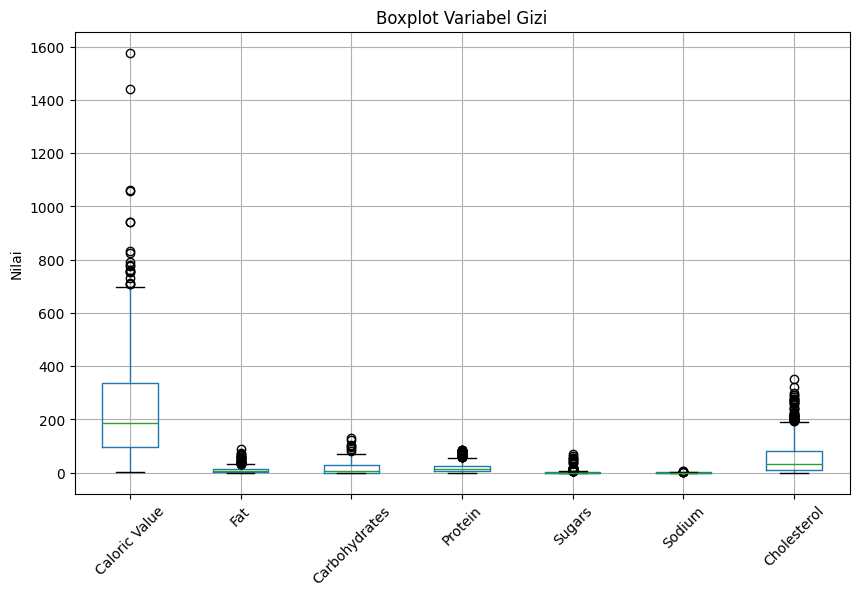

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

kolom = ['Caloric Value','Fat','Carbohydrates','Protein','Sugars','Sodium','Cholesterol']

df[kolom] = df[kolom].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(10,6))
df[kolom].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot Variabel Gizi")
plt.ylabel("Nilai")
plt.grid(True)

plt.show()

## **Penjelasan Visualisasi Boxplot**



Berdasarkan boxplot yang ditampilkan, terlihat bahwa hampir semua variabel memiliki outlier yang ditandai dengan titik-titik di luar whisker.

Variabel Caloric Value menunjukkan sebaran data yang paling luas dibandingkan variabel lainnya, dengan beberapa nilai yang jauh lebih tinggi dari mayoritas data. Hal ini menunjukkan adanya makanan dengan kandungan kalori yang sangat tinggi.

Variabel Cholesterol dan Carbohydrates juga memiliki cukup banyak outlier, yang menunjukkan adanya makanan dengan kandungan kolesterol dan karbohidrat yang jauh lebih tinggi dibandingkan sebagian besar data.

Sementara itu, variabel seperti Protein, Fat, dan Sugars memiliki outlier, namun tidak se-ekstrem Caloric Value.

Variabel Sodium terlihat memiliki sebaran yang relatif kecil dibandingkan variabel lain, namun tetap terdapat beberapa outlier.

## **Penjelasan Data Outlier**

In [9]:
import pandas as pd

kolom = ['Caloric Value','Fat','Carbohydrates','Protein','Sugars','Sodium','Cholesterol']

for col in kolom:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n=== {col} ===")
    print(f"Batas bawah: {lower}")
    print(f"Batas atas: {upper}")
    print(f"Jumlah outlier: {len(outliers)}")


=== Caloric Value ===
Batas bawah: -269.25
Batas atas: 700.75
Jumlah outlier: 19

=== Fat ===
Batas bawah: -15.350000000000001
Batas atas: 32.25
Jumlah outlier: 35

=== Carbohydrates ===
Batas bawah: -43.05
Batas atas: 71.75
Jumlah outlier: 7

=== Protein ===
Batas bawah: -25.224999999999998
Batas atas: 56.175
Jumlah outlier: 36

=== Sugars ===
Batas bawah: -3.3000000000000003
Batas atas: 5.5
Jumlah outlier: 82

=== Sodium ===
Batas bawah: -1.1
Batas atas: 2.1
Jumlah outlier: 8

=== Cholesterol ===
Batas bawah: -99.60000000000001
Batas atas: 192.0
Jumlah outlier: 44




Berdasarkan perhitungan menggunakan metode Interquartile Range (IQR), diperoleh batas bawah dan batas atas untuk masing-masing variabel, serta jumlah data yang tergolong sebagai outlier.

Hasil analisis menunjukkan bahwa:

- Variabel Sugars memiliki jumlah outlier paling banyak, yaitu sebanyak 82 data. Hal ini menunjukkan adanya banyak makanan dengan kandungan gula yang jauh lebih tinggi dibandingkan mayoritas data.
- Variabel Cholesterol juga memiliki jumlah outlier yang cukup tinggi, yaitu sebanyak 44 data, yang mengindikasikan adanya makanan dengan kandungan kolesterol tinggi.
- Variabel Protein dan Fat masing-masing memiliki 36 dan 35 outlier, yang menunjukkan variasi kandungan nutrisi yang cukup besar.
- Variabel Caloric Value memiliki 19 outlier, yang berarti terdapat beberapa makanan dengan kandungan kalori yang sangat tinggi dibandingkan sebagian besar data.
- Variabel Carbohydrates memiliki jumlah outlier yang relatif sedikit, yaitu 7 data, sehingga distribusinya lebih stabil dibandingkan variabel lainnya.

Selain itu, ditemukan bahwa beberapa batas bawah bernilai negatif. Hal ini tidak menjadi masalah dalam metode IQR, karena secara matematis batas tersebut merupakan hasil perhitungan, meskipun secara nyata nilai nutrisi tidak mungkin negatif.

Outlier yang ditemukan dalam dataset ini tidak selalu merupakan kesalahan data, melainkan dapat mencerminkan kondisi nyata, seperti makanan dengan kandungan gula, lemak, atau kolesterol yang sangat tinggi. Oleh karena itu, outlier penting untuk dianalisis karena dapat memberikan informasi mengenai variasi ekstrem dalam data serta mempengaruhi hasil analisis statistik.

In [10]:
for col in kolom:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\nOutlier pada {col}:")
    print(outliers[['food', col]].head())


Outlier pada Caloric Value:
                     food  Caloric Value
17         gjetost cheese           1058
47          cheese spread            708
66       kung pao chicken            779
83          lemon chicken           1440
153  general tsos chicken           1578

Outlier pada Fat:
                 food   Fat
11  port salut cheese  37.2
17     gjetost cheese  67.0
29   chihuahua cheese  39.2
31    muenster cheese  39.7
34     pimento cheese  43.7

Outlier pada Carbohydrates:
                              food  Carbohydrates
17                  gjetost cheese           96.8
83                   lemon chicken          122.0
153           general tsos chicken          128.3
165                    apple crisp           87.0
281  hotcakes with syrup mcdonalds          101.8

Outlier pada Protein:
                                       food  Protein
66                         kung pao chicken     59.0
83                            lemon chicken     68.6
153                    gene



Berdasarkan hasil perhitungan menggunakan metode Interquartile Range (IQR), ditemukan sejumlah data yang tergolong sebagai outlier pada beberapa variabel utama. Outlier tersebut ditandai dengan nilai yang berada di luar batas bawah maupun batas atas yang telah ditentukan.

Pada variabel Caloric Value, ditemukan beberapa makanan dengan kandungan kalori yang sangat tinggi, seperti gjetost cheese (1058 kcal), lemon chicken (1440 kcal), dan general tsos chicken (1578 kcal). Nilai ini jauh di atas batas atas yang telah dihitung, sehingga dikategorikan sebagai outlier.

Pada variabel Fat, terdapat makanan dengan kandungan lemak yang tinggi, seperti gjetost cheese (67.0 g), pimento cheese (43.7 g), dan muenster cheese (39.7 g). Hal ini menunjukkan adanya makanan dengan kandungan lemak yang jauh lebih tinggi dibandingkan mayoritas data.

Pada variabel Carbohydrates, juga ditemukan outlier seperti general tsos chicken (128.3 g), lemon chicken (122.0 g), serta beberapa makanan lain seperti apple crisp dan hotcakes with syrup yang memiliki kandungan karbohidrat tinggi.

Keberadaan outlier ini dapat disebabkan oleh variasi jenis makanan dalam dataset, seperti makanan olahan, makanan cepat saji, atau makanan dengan kandungan gula dan lemak tinggi.

